<a href="https://colab.research.google.com/github/Sargam2808/DEEP_LEARNING_LAB/blob/main/Dl_lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB EXPERIMENT 5


Uploading Dataset

In [1]:
from google.colab import files
uploaded = files.upload()


Saving poems-100.csv to poems-100.csv


In [3]:
import pandas as pd

In [4]:
# read CSV file
df = pd.read_csv("poems-100.csv")   # change filename if needed



first 5 rows

In [9]:
pd.set_option("display.max_colwidth", None)


In [10]:
df.head()


,text
0,"O my Luve's like a red, red rose\nThat’s newly sprung in June;\nO my Luve's like the melodie\nThat’s sweetly play'd in tune.\n\nAs fair art thou, my bonnie lass,\nSo deep in luve am I:\nAnd I will luve thee still, my dear,\nTill a’ the seas gang dry:\n\nTill a’ the seas gang dry, my dear,\nAnd the rocks melt wi’ the sun:\nI will luve thee still, my dear,\nWhile the sands o’ life shall run.\n\nAnd fare thee well, my only Luve\nAnd fare thee well, a while!\nAnd I will come again, my Luve,\nTho’ it were ten thousand mile."
1,"The rose is red,\nThe violet's blue,\nSugar is sweet,\nAnd so are you."
2,"How do I love thee? Let me count the ways.\nI love thee to the depth and breadth and height\nMy soul can reach, when feeling out of sight\nFor the ends of being and ideal grace.\nI love thee to the level of every day's\nMost quiet need, by sun and candle-light.\nI love thee freely, as men strive for right.\nI love thee purely, as they turn from praise.\nI love thee with the passion put to use\nIn my old griefs, and with my childhood's faith.\nI love thee with a love I seemed to lose\nWith my lost saints. I love with the breath,\nSmiles, tears, of all my life; and, if God choose,\nI shall but love thee better after death.\n"
3,"Had I the heavens' embroidered cloths,\nEnwrought with golden and silver light,\nThe blue and the dim and the dark cloths\nOf night and light and the half-light,\nI would spread the cloths under your feet:\nBut I, being poor, have only my dreams;\nI have spread my dreams under your feet;\nTread softly because you tread on my dreams."
4,"I.\n Enough! we're tired, my heart and I.\n We sit beside the headstone thus,\n And wish that name were carved for us.\n The moss reprints more tenderly\n The hard types of the mason's knife,\n As heaven's sweet life renews earth's life\n With which we're tired, my heart and I.\n\nII.\n You see we're tired, my heart and I.\n We dealt with books, we trusted men,\n And in our own blood drenched the pen,\n As if such colours could not fly.\n We walked too straight for fortune's end,\n We loved too true to keep a friend;\n At last we're tired, my heart and I.\n\nIII.\n How tired we feel, my heart and I!\n We seem of no use in the world;\n Our fancies hang grey and uncurled\n About men's eyes indifferently;\n Our voice which thrilled you so, will let\n You sleep; our tears are only wet:\n What do we here, my heart and I?\n\nIV.\n So tired, so tired, my heart and I!\n It was not thus in that old time\n When Ralph sat with me 'neath the lime\n To watch the sunset from the sky.\n Dear love, you're looking tired,' he said;\n I, smiling at him, shook my head:\n 'Tis now we're tired, my heart and I.\n\nV.\n So tired, so tired, my heart and I!\n Though now none takes me on his arm\n To fold me close and kiss me warm\n Till each quick breath end in a sigh\n Of happy languor. Now, alone,\n We lean upon this graveyard stone,\n Uncheered, unkissed, my heart and I.\n\nVI.\n Tired out we are, my heart and I.\n Suppose the world brought diadems\n To tempt us, crusted with loose gems\n Of powers and pleasures? Let it try.\n We scarcely care to look at even\n A pretty child, or God's blue heaven,\n We feel so tired, my heart and I.\n\nVII.\n Yet who complains? My heart and I?\n In this abundant earth no doubt\n Is little room for things worn out:\n Disdain them, break them, throw them by\n And if before the days grew rough\n We once were loved, used, well enough,\n I think, we've fared, my heart and I."


datset shape

In [11]:
print("Dataset shape (rows, columns):", df.shape)


Dataset shape (rows, columns): (100, 1)


column names

In [12]:
print("Column names:")
print(df.columns)


Column names:
Index(['text'], dtype='object')


datset info

In [13]:
print("Dataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    100 non-null    object
dtypes: object(1)
memory usage: 932.0+ bytes


checking missing value

In [14]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
text    0
dtype: int64


length of each poem

In [16]:
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
print("Word count statistics:")
df["word_count"].describe()


Word count statistics:


,word_count
count,100.0000
mean,247.3400
std,247.7752
min,14.0000
25%,101.2500
50%,192.0000
75%,319.5000
max,1958.0000


sample from datset

In [18]:
print("Sample poem from dataset:\n")
print(df["text"].iloc[0])


Sample poem from dataset:

O my Luve's like a red, red rose
That’s newly sprung in June;
O my Luve's like the melodie
That’s sweetly play'd in tune.

As fair art thou, my bonnie lass,
So deep in luve am I:
And I will luve thee still, my dear,
Till a’ the seas gang dry:

Till a’ the seas gang dry, my dear,
And the rocks melt wi’ the sun:
I will luve thee still, my dear,
While the sands o’ life shall run.

And fare thee well, my only Luve
And fare thee well, a while!
And I will come again, my Luve,
Tho’ it were ten thousand mile.


Importing Libraries

In [20]:
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
import matplotlib.pyplot as plt
import time


Preprocessing

In [28]:
raw_text = " ".join(df["text"].astype(str).tolist())
print("Raw text length:", len(raw_text))


Raw text length: 139230


In [29]:
raw_text = raw_text.lower()
raw_text = re.sub(r"[^a-z\s]", "", raw_text)

tokens = raw_text.split()

print("Total tokens:", len(tokens))
print("First 20 tokens:", tokens[:20])


Total tokens: 24676
First 20 tokens: ['o', 'my', 'luves', 'like', 'a', 'red', 'red', 'rose', 'thats', 'newly', 'sprung', 'in', 'june', 'o', 'my', 'luves', 'like', 'the', 'melodie', 'thats']


In [30]:
vocab = sorted(set(tokens))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
vocab_size = len(vocab)

print("Vocabulary size:", vocab_size)


Vocabulary size: 5439


RNN FROM SCRATCH(Numpy)

In [33]:
# Hyperparameters
hidden_size = 50
learning_rate = 0.01

Wxh = np.random.randn(hidden_size, vocab_size) * 0.01
Whh = np.random.randn(hidden_size, hidden_size) * 0.01
Why = np.random.randn(vocab_size, hidden_size) * 0.01
bh = np.zeros((hidden_size, 1))
by = np.zeros((vocab_size, 1))


In [34]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

def one_hot(idx):
    vec = np.zeros((vocab_size, 1))
    vec[idx] = 1
    return vec


In [35]:
def forward(inputs, targets, hprev):
    xs, hs, ys, ps = {}, {}, {}, {}
    hs[-1] = np.copy(hprev)
    loss = 0

    for t in range(len(inputs)):
        xs[t] = one_hot(inputs[t])
        hs[t] = np.tanh(Wxh @ xs[t] + Whh @ hs[t-1] + bh)
        ys[t] = Why @ hs[t] + by
        ps[t] = softmax(ys[t])
        loss += -np.log(ps[t][targets[t], 0])
    return loss, hs[len(inputs)-1]


In [36]:
sample_input = [word2idx[tokens[i]] for i in range(5)]
sample_target = [word2idx[tokens[i+1]] for i in range(5)]

loss, _ = forward(sample_input, sample_target, np.zeros((hidden_size,1)))
print("Sample Loss:", loss)


Sample Loss: 43.007881011004464


ONE HOT ENCODING(Py-Torch)

In [37]:
seq_len = 5
X = []
Y = []

for i in range(len(tokens)-seq_len):
    X.append([word2idx[tokens[i+j]] for j in range(seq_len)])
    Y.append(word2idx[tokens[i+seq_len]])

X = torch.tensor(X)
Y = torch.tensor(Y)


Sample of tokenization

In [39]:
print("Original lines:")
print(raw_text.split("\n")[:3])

print("\nTokenized words:")
print(tokens[:8])


Original lines:
['o my luves like a red red rose', 'thats newly sprung in june', 'o my luves like the melodie']

Tokenized words:
['o', 'my', 'luves', 'like', 'a', 'red', 'red', 'rose']


RNN Model(One-Hot)

In [40]:
class RNN_OneHot(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = nn.functional.one_hot(x, vocab_size).float()
        out, _ = self.rnn(x)
        out = self.fc(out[:,-1,:])
        return out


Training

In [41]:
model_oh = RNN_OneHot(vocab_size, 128)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_oh.parameters(), lr=0.001)

losses_oh = []
start = time.time()

for epoch in range(10):
    optimizer.zero_grad()
    outputs = model_oh(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()

    losses_oh.append(loss.item())
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

time_oh = time.time() - start


Epoch 1, Loss: 8.5885
Epoch 2, Loss: 8.5665
Epoch 3, Loss: 8.5432
Epoch 4, Loss: 8.5166
Epoch 5, Loss: 8.4847
Epoch 6, Loss: 8.4447
Epoch 7, Loss: 8.3934
Epoch 8, Loss: 8.3269
Epoch 9, Loss: 8.2412
Epoch 10, Loss: 8.1329


sample vector length

In [42]:
sample_word = tokens[15]
vec = torch.nn.functional.one_hot(
    torch.tensor(word2idx[sample_word]),
    vocab_size
)

print("Word:", sample_word)
print("One-hot vector length:", vec.shape[0])
print("Number of non-zero elements:", vec.sum().item())


Word: luves
One-hot vector length: 5439
Number of non-zero elements: 1


Semnatic meaning example using one hot encoding(it fails to capture)

In [43]:
import torch

w1 = torch.nn.functional.one_hot(
    torch.tensor(word2idx["love"]),
    vocab_size
).float()

w2 = torch.nn.functional.one_hot(
    torch.tensor(word2idx["heart"]),
    vocab_size
).float()

cos_sim = torch.nn.functional.cosine_similarity(w1, w2, dim=0)
print("Cosine similarity between 'love' and 'heart' (One-Hot):", cos_sim.item())


Cosine similarity between 'love' and 'heart' (One-Hot): 0.0


One-Hot Loss Plot

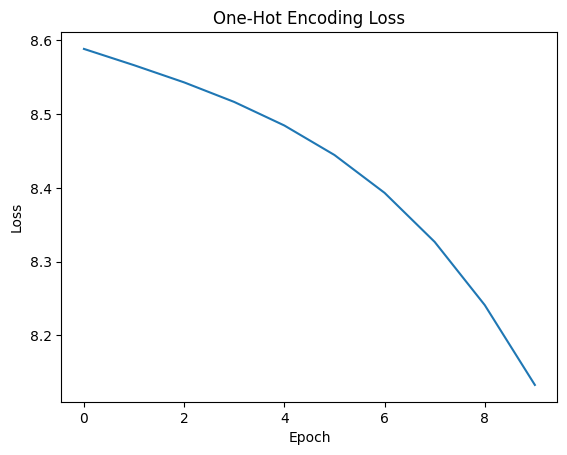

In [44]:
plt.plot(losses_oh)
plt.title("One-Hot Encoding Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


Trainable Word embeddings

In [45]:
class RNN_Embedding(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.rnn(x)
        out = self.fc(out[:,-1,:])
        return out


Training

In [46]:
model_emb = RNN_Embedding(vocab_size, 50, 128)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_emb.parameters(), lr=0.001)

losses_emb = []
start = time.time()

for epoch in range(10):
    optimizer.zero_grad()
    outputs = model_emb(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()

    losses_emb.append(loss.item())
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

time_emb = time.time() - start


Epoch 1, Loss: 8.6362
Epoch 2, Loss: 8.6059
Epoch 3, Loss: 8.5761
Epoch 4, Loss: 8.5457
Epoch 5, Loss: 8.5139
Epoch 6, Loss: 8.4796
Epoch 7, Loss: 8.4413
Epoch 8, Loss: 8.3973
Epoch 9, Loss: 8.3455
Epoch 10, Loss: 8.2834


In [47]:
print("Sample word to index mapping:")
for w in list(word2idx.keys())[:10]:
    print(f"{w} -> {word2idx[w]}")


Sample word to index mapping:
a -> 0
abase -> 1
abased -> 2
abbeystones -> 3
abeyance -> 4
abide -> 5
abode -> 6
abodes -> 7
about -> 8
above -> 9


Example of Semantic menaing using embeddings

In [48]:
import torch.nn.functional as F

def semantic_similarity(word, topk=5):
    idx = word2idx[word]
    vec = model_emb.embed.weight[idx]
    similarity = F.cosine_similarity(
        vec.unsqueeze(0),
        model_emb.embed.weight
    )
    top_indices = torch.topk(similarity, topk+1).indices.tolist()
    return [idx2word[i] for i in top_indices if i != idx][:topk]

print("Words semantically similar to 'love':")
print(semantic_similarity("love"))

print("\nWords semantically similar to 'night':")
print(semantic_similarity("night"))


Words semantically similar to 'love':
['blow', 'cloths', 'axes', 'number', 'motor']

Words semantically similar to 'night':
['swims', 'mockings', 'loft', 'seemest', 'assume']


In [49]:
v1 = model_emb.embed.weight[word2idx["love"]]
v2 = model_emb.embed.weight[word2idx["heart"]]

cos_sim = torch.nn.functional.cosine_similarity(v1, v2, dim=0)
print("Cosine similarity between 'love' and 'heart' (Embedding):", cos_sim.item())


Cosine similarity between 'love' and 'heart' (Embedding): 0.07591904699802399


Embedding Loss Plot

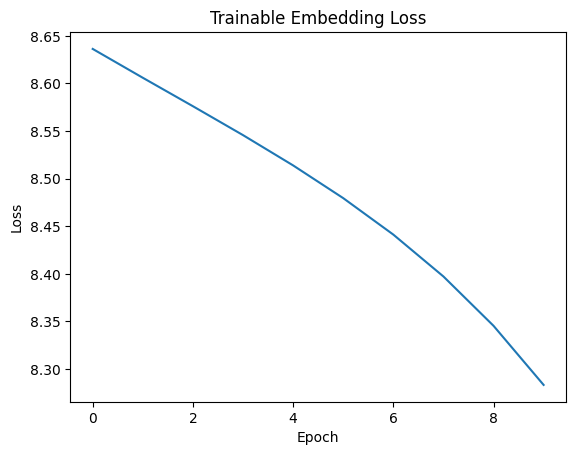

In [50]:
plt.plot(losses_emb)
plt.title("Trainable Embedding Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


Text Generation

In [51]:
def generate_text_verbose(model, start_word, length=10):
    model.eval()
    word = start_word
    print("Start word:", word)

    for i in range(length):
        x = torch.tensor([[word2idx[word]]])
        out = model(x)
        probs = torch.softmax(out, dim=1)

        next_idx = torch.argmax(probs).item()
        next_word = idx2word[next_idx]

        print(f"Step {i+1}: '{word}' → '{next_word}'")
        word = next_word


In [52]:
print("Embedding model generation steps:")
generate_text_verbose(model_emb, "love")


Embedding model generation steps:
Start word: love
Step 1: 'love' → 'original'
Step 2: 'original' → 'itself'
Step 3: 'itself' → 'really'
Step 4: 'really' → 'now'
Step 5: 'now' → 'one'
Step 6: 'one' → 'after'
Step 7: 'after' → 'gladness'
Step 8: 'gladness' → 'meteors'
Step 9: 'meteors' → 'crowded'
Step 10: 'crowded' → 'can'


In [53]:
print("Embedding model generation steps:")
generate_text_verbose(model_oh, "love")

Embedding model generation steps:
Start word: love
Step 1: 'love' → 'young'
Step 2: 'young' → 'through'
Step 3: 'through' → 'soft'
Step 4: 'soft' → 'through'
Step 5: 'through' → 'soft'
Step 6: 'soft' → 'through'
Step 7: 'through' → 'soft'
Step 8: 'soft' → 'through'
Step 9: 'through' → 'soft'
Step 10: 'soft' → 'through'


Comparing no. of parameters

In [54]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("One-Hot RNN Parameters:", count_params(model_oh))
print("Embedding RNN Parameters:", count_params(model_emb))


One-Hot RNN Parameters: 1414463
Embedding RNN Parameters: 996621


COMPARISON

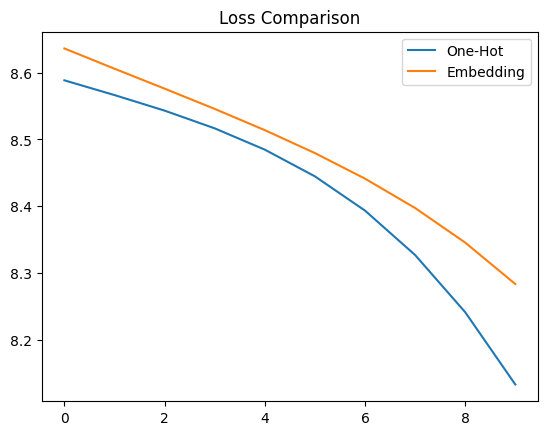

In [55]:
plt.plot(losses_oh, label="One-Hot")
plt.plot(losses_emb, label="Embedding")
plt.legend()
plt.title("Loss Comparison")
plt.show()


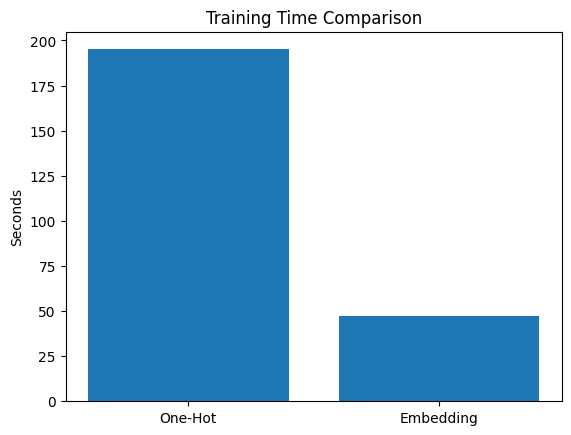

In [56]:
plt.bar(["One-Hot", "Embedding"], [time_oh, time_emb])
plt.ylabel("Seconds")
plt.title("Training Time Comparison")
plt.show()
